The goal is to build an underwriting model that:
- Predicts claim probability (frequency)
- Produces a calibrated risk score
- Supports pricing decisions
- Remains interpretable for underwriting use

In [176]:
import seaborn as sns
sns.set_style("whitegrid")

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [177]:
import pandas as pd

df = pd.read_csv("insurance_dataset.csv")
df.columns

Index(['age', 'driver_type', 'years_experience', 'income_band', 'vehicle_age',
       'vehicle_type', 'vehicle_value', 'airbags', 'tracking_device', 'region',
       'traffic_density', 'policy_duration', 'annual_mileage',
       'speeding_score', 'previous_claims', 'fraud_flag', 'risk_score',
       'base_premium', 'premium', 'claim_occurred', 'claim_amount',
       'claim_type'],
      dtype='object')

### Feature Selection
Removing leakage columns
- premium depends on risk_score
- claim_amount and claim_type only exists after claim

In [178]:
drop_cols = ["claim_occurred", "claim_amount", "premium", "base_premium", "risk_score", "claim_type"]

X = df.drop(columns=drop_cols)
y = df["claim_occurred"]

### Feature Engineering

We create underwriting factors by converting raw features

In [179]:
# Safety Score
X["safety_score"] = (X["airbags"] * 0.5 + X["tracking_device"] * 2)

In [180]:
# Behavioral Risk Score
speed_map = {"low":0, "medium":1, "high":2}

X["behavior_score"] = (X["annual_mileage"] / 10000 + X["previous_claims"] * 2 + X["speeding_score"].map(speed_map))

In [181]:
# Age Buckets (Non-linear risk)
X["age_band"] = pd.cut(X["age"], bins=[20,30,50,70], labels=["young","mid","older"])

# Vehicle Age Bands
X["vehicle_age_band"] = pd.cut(X["vehicle_age"], bins=[0,3,7,15], labels=["new","mid","old"])

# Mileage Risk
X["high_mileage"] = (X["annual_mileage"] > 25000).astype(int)

In [182]:
X.columns

Index(['age', 'driver_type', 'years_experience', 'income_band', 'vehicle_age',
       'vehicle_type', 'vehicle_value', 'airbags', 'tracking_device', 'region',
       'traffic_density', 'policy_duration', 'annual_mileage',
       'speeding_score', 'previous_claims', 'fraud_flag', 'safety_score',
       'behavior_score', 'age_band', 'vehicle_age_band', 'high_mileage'],
      dtype='object')

In [183]:
# Encoding Categoricals
X = pd.get_dummies(X, drop_first=True)

In [184]:
# Checking correlation to ensure no more leakage

for col in X.columns:
    corr = np.corrcoef(X[col], y)[0,1]
    print(col, corr)

age -0.005339773253949257
years_experience -0.0053397732539492496
vehicle_age -0.0025390574104918015
vehicle_value 0.009288366568738602
airbags -0.01815170986279918
tracking_device -0.012930473790794005
policy_duration -0.031007667404553314
annual_mileage 0.023772666229835
previous_claims 0.019360780533355694
fraud_flag 0.009116713103017897
safety_score -0.022160562640052634
behavior_score 0.031092123722143785
high_mileage 0.020568417694979583
driver_type_private -0.02206090392173993
driver_type_taxi -0.006262202662633946
income_band_low 0.002665818136981779
income_band_middle -0.004172151286774123
vehicle_type_pickup 0.028613700462657345
vehicle_type_sedan -0.009760774771387051
vehicle_type_truck 0.017046572015554595
region_Mombasa -0.02201142096854967
region_Nairobi 0.045282586682462364
region_Rural -0.015497291669074053
traffic_density_low -0.015497291669074053
traffic_density_medium -0.03224974395486062
speeding_score_low 0.005953090829809766
speeding_score_medium -0.02836852861867

### Train-Test Split

In [185]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [186]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (40000, 31)
Test shape: (10000, 31)


In [187]:
# Class Imbalance

print(y_train.value_counts(normalize=True))

claim_occurred
0    0.916225
1    0.083775
Name: proportion, dtype: float64


### Model Training
#### Logistic Regression

In [188]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [189]:
coefficients = pd.Series(lr.coef_[0], index=X.columns)
coefficients.sort_values(ascending=False).head(10)

region_Nairobi          0.184286
vehicle_type_pickup     0.057536
age_band_older          0.052879
behavior_score          0.049449
speeding_score_low      0.037027
vehicle_type_truck      0.020822
fraud_flag              0.019920
age                     0.009278
vehicle_age             0.004261
vehicle_age_band_old    0.003850
dtype: float64

- positive increases risk
- negative reduces risk

In [190]:
y_pred_proba = lr.predict_proba(X_test)[:,1]

y_pred = (y_pred_proba > 0.6).astype(int)

In [191]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_pred_proba)

np.float64(0.577346948769927)

- Many false positives, model is flagging low-risk policies as high-risk.

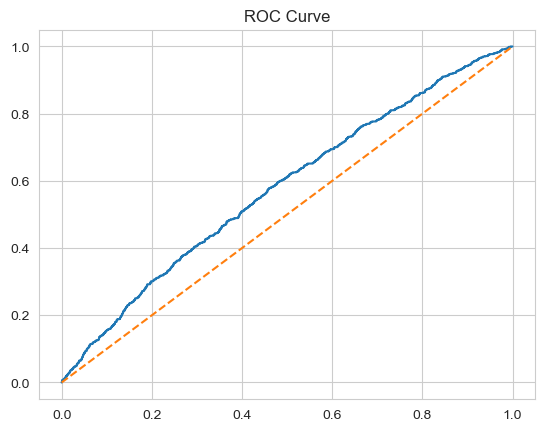

In [192]:
# ploting True Positive Rate (Recall) vs False Positive Rate at every possible threshold.

import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC Curve")
plt.show()

In [193]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[8608,  554],
       [ 750,   88]])

- 8608 (TN) - correctly predicted no claim
- 554 (TP) - predicted claim correctly
- 750 (FN) - missed claims
- 88 (FP) - predicted claim incorrectly

##### LR Risk Score Creation

In [194]:
df_test = X_test.copy()
df_test["actual"] = y_test.values

df_test["lr_predicted_risk"] = y_pred_proba

df_test["lr_risk_band"] = pd.cut(df_test["lr_predicted_risk"], bins=[0,0.05,0.1,0.2,1], labels=["Low","Medium","High","Very High"])

df_test.groupby("lr_risk_band", observed=True)["actual"].mean()

lr_risk_band
Very High    0.0838
Name: actual, dtype: float64

0nly ~8% of policies in “Very High” actually claimed. This is much lower than what we’d expect for a high-risk band.
- The logistic regression isn’t separating the extremes well.

### Gradient Boosting Model

In [195]:
from sklearn.ensemble import GradientBoostingClassifier
gbm = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)

gbm.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=5, n_estimators=200, random_state=42)

In [196]:
from sklearn.metrics import roc_auc_score, classification_report

gbm_pred_proba = gbm.predict_proba(X_test)[:,1]
y_pred = (gbm_pred_proba > 0.6).astype(int)

roc_auc_score(y_test, y_pred)
print("ROC-AUC:", roc_auc_score(y_test, gbm_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ROC-AUC: 0.549133757311381

Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96      9162
           1       0.17      0.00      0.00       838

    accuracy                           0.92     10000
   macro avg       0.54      0.50      0.48     10000
weighted avg       0.85      0.92      0.88     10000



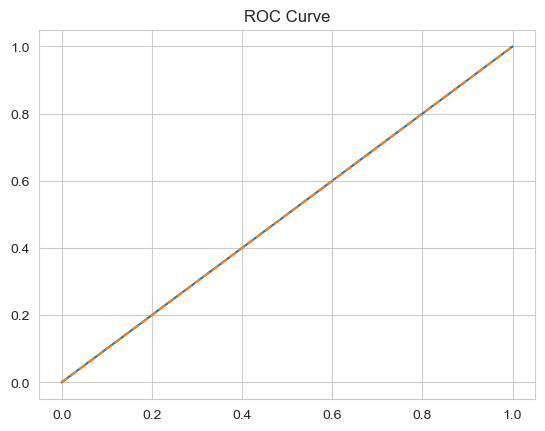

In [197]:
fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC Curve")
plt.show()

In [198]:
confusion_matrix(y_test, y_pred)

array([[9157,    5],
       [ 837,    1]])

- 9157 (TN) - correctly predicted no claim
- 5 (TP) - predicted claim correctly
- 837 (FN) - missed claims
- 1 (FP) - predicted claim incorrectly

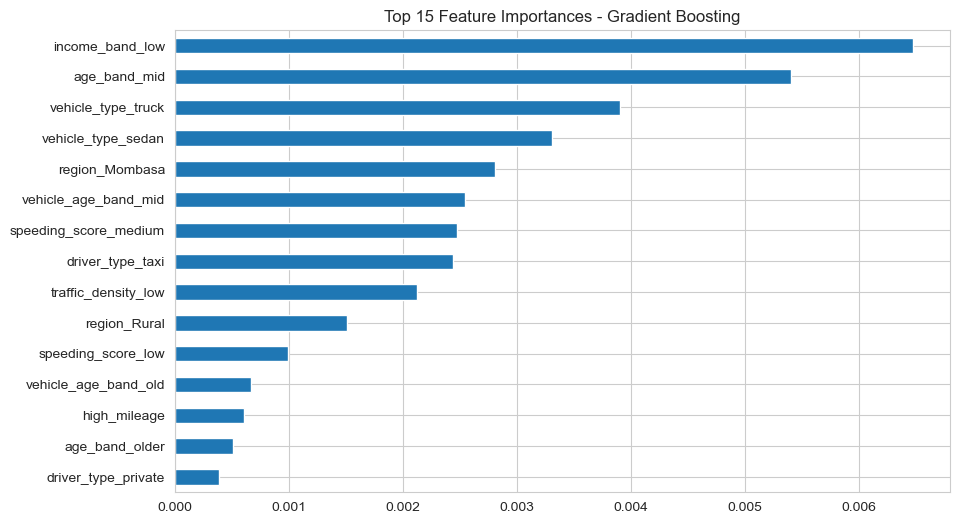

In [199]:
importances = pd.Series(gbm.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).head(15).plot(kind="barh", figsize=(10,6))
plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.show()

In [201]:
df_test["gb_predicted_risk"] = gbm_pred_proba

df_test["gb_risk_band"] = pd.cut(df_test["gb_predicted_risk"], bins=[0,0.05,0.1,0.2,1], labels=["Low","Medium","High","Very High"])

df_test.groupby("gb_risk_band", observed=True)["actual"].mean()

gb_risk_band
Low          0.066613
Medium       0.080184
High         0.109189
Very High    0.076923
Name: actual, dtype: float64

#### Random Forest

In [202]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

- Synthetic samples from oversampling impacted the models negatively. We will be fitting on the data as is.

In [203]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", max_depth=10, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [243]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

behavior_score      0.127773
annual_mileage      0.125361
vehicle_value       0.122664
age                 0.075222
years_experience    0.072552
vehicle_age         0.068210
safety_score        0.062130
airbags             0.051682
policy_duration     0.041577
previous_claims     0.024471
dtype: float64

- RF thinks behavioral features are top predictors. This is expected

In [244]:
rf_pred = rf.predict_proba(X_test)[:,1]

y_pred = (rf_pred > 0.6).astype(int)

In [245]:
roc_auc_score(y_test, rf_pred)

np.float64(0.5541723388969382)

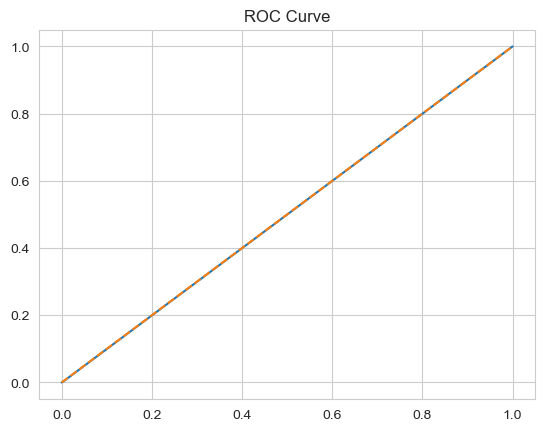

In [246]:
fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC Curve")
plt.show()

In [247]:
confusion_matrix(y_test, y_pred)

array([[9145,   17],
       [ 837,    1]])

- 9145 (TN) - correctly predicted no claim
- 17 (TP) - predicted claim correctly
- 837 (FN) - missed claims
- 1 (FP) - predicted claim incorrectly

The model is better at detecting claims, but many false alarms (typical tradeoff for rare event detection).

##### RF Risk Score Creation

In [248]:
df_test["rf_predicted_risk"] = rf_pred

df_test["rf_risk_band"] = pd.qcut(df_test["rf_predicted_risk"], 4, labels=["Low","Medium","High","Very High"])

df_test.groupby("rf_risk_band", observed=True)["actual"].mean()

rf_risk_band
Low          0.0948
Medium       0.0764
High         0.0884
Very High    0.0756
Name: actual, dtype: float64

##### Conclusion

Random Forest performs better than Gradient Boosting. This may be explained by the fact that Gradient Boosting aggressively focuses on misclassified samples.

In our dataset, the minority class (claims) has complex, discrete patterns. Boosting can overfit synthetic noise or small variations, reducing performance.

In [251]:
# Saving the model
import joblib
joblib.dump(rf, 'model.pkl')

['model.pkl']

In [252]:
feature_columns = X_train.columns

# Save it
import joblib
joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

### Pricing Model (Expected Loss and Premium)

In [249]:
df_test["expected_loss"] = df_test["rf_predicted_risk"] * df.loc[df_test.index, "vehicle_value"]

expense_loading = 0.3
profit_margin = 0.1

df_test["technical_premium"] = df_test["expected_loss"] * (1 + expense_loading + profit_margin)

In [250]:
df_test.head()

,age,years_experience,vehicle_age,vehicle_value,airbags,tracking_device,policy_duration,annual_mileage,previous_claims,fraud_flag,...,gb_predicted_risk,gb_risk_band,rf_predicted_risk,rf_risk_band,expected_loss,technical_premium,pred_bin,cumulative_claims,cumulative_total,pred_decile
46588,23,5,9,1.778771e+06,1,0,6,25242,0,0,...,0.152981,High,0.440368,High,783314.074383,1.096640e+06,"(0.507, 0.653]",11,114,9
23063,61,43,2,9.991596e+05,1,0,3,18353,1,0,...,0.105958,High,0.458168,High,457782.478326,6.408955e+05,"(0.507, 0.653]",180,1611,9
15609,53,35,0,1.379448e+06,0,0,3,13474,1,0,...,0.118068,High,0.283222,Low,390690.173746,5.469662e+05,"(0.507, 0.653]",37,422,9
28914,58,40,7,7.904495e+05,0,0,6,16736,0,0,...,0.122875,High,0.342713,Low,270897.390637,3.792563e+05,"(0.507, 0.653]",167,1441,9
3946,44,26,3,1.276753e+06,1,1,12,27540,0,0,...,0.065356,Medium,0.433688,High,553712.333112,7.751973e+05,"(0.507, 0.653]",469,4892,9
